# 📋 Notebook 01 — Data Ingestion

| Item | Detail |
|------|--------|
| **Objective** | Load all raw data sources, perform structural inspection, and persist a data inventory report. |
| **Question** | *"What do we have?"* |
| **Dependencies** | Notebook `00` — raw dataset in `data/raw/`, `src/adoption_accelerator` importable |
| **Artifacts** | `reports/data_inventory.json` |
| **Scope** | Read-only — no data transformations |
| **Expected Runtime** | < 2 min |

---
## 1 · Imports & Configuration

In [1]:
from __future__ import annotations

import json
import logging
import warnings
from datetime import datetime, timezone
from pathlib import Path
from pprint import pprint

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from adoption_accelerator import config as cfg
from adoption_accelerator.data.ingestion import (
    EXPECTED_TEST_COLUMNS,
    EXPECTED_TRAIN_COLUMNS,
    get_file_inventory,
    load_image,
    load_metadata_json,
    load_reference_table,
    load_sentiment_json,
    load_tabular,
)
from adoption_accelerator.utils.logging import setup_logging

# ── Global defaults ──────────────────────────────────────────────
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 30)
pd.set_option("display.max_colwidth", 60)
pd.set_option("display.float_format", "{:.4f}".format)
plt.rcParams.update({"figure.dpi": 100, "figure.figsize": (10, 3)})

logger = setup_logging(logging.INFO)
SEED = cfg.SEED
np.random.seed(SEED)

logger.info("Notebook 01 — Data Ingestion started")

00:36:30  INFO      Notebook 01 — Data Ingestion started


---
## 2 · Load Tabular Data

In [2]:
df_train = load_tabular("train")
df_test  = load_tabular("test")

00:36:37  INFO      Loading train data from /workspaces/adoption_accelerator/data/raw/train/train.csv
00:36:37  INFO      Loaded train: 14993 rows × 24 columns
00:36:37  INFO      Loading test data from /workspaces/adoption_accelerator/data/raw/test/test.csv
00:36:37  INFO      Loaded test: 3972 rows × 23 columns


---
## 3 · Inspect Tabular Data

### 3.1 · Training Set

In [3]:
print(f"Shape: {df_train.shape[0]:,} rows × {df_train.shape[1]} columns")
print(f"Memory usage: {df_train.memory_usage(deep=True).sum() / 1_048_576:.2f} MB")
df_train.head()

Shape: 14,993 rows × 24 columns
Memory usage: 11.18 MB


,Type,Name,Age,Breed1,Breed2,Gender,Color1,Color2,Color3,MaturitySize,FurLength,Vaccinated,Dewormed,Sterilized,Health,Quantity,Fee,State,RescuerID,VideoAmt,Description,PetID,PhotoAmt,AdoptionSpeed
0,2,Nibble,3,299,0,1,1,7,0,1,1,2,2,2,1,1,100,41326,8480853f516546f6cf33aa88cd76c379,0,Nibble is a 3+ month old ball of cuteness. He is energet...,86e1089a3,1.0000,2
1,2,No Name Yet,1,265,0,1,1,2,0,2,2,3,3,3,1,1,0,41401,3082c7125d8fb66f7dd4bff4192c8b14,0,I just found it alone yesterday near my apartment. It wa...,6296e909a,2.0000,0
2,1,Brisco,1,307,0,1,2,7,0,2,2,1,1,2,1,1,0,41326,fa90fa5b1ee11c86938398b60abc32cb,0,Their pregnant mother was dumped by her irresponsible ow...,3422e4906,7.0000,3
3,1,Miko,4,307,0,2,1,2,0,2,1,1,1,2,1,1,150,41401,9238e4f44c71a75282e62f7136c6b240,0,"Good guard dog, very alert, active, obedience waiting fo...",5842f1ff5,8.0000,2
4,1,Hunter,1,307,0,1,1,0,0,2,1,2,2,2,1,1,0,41326,95481e953f8aed9ec3d16fc4509537e8,0,This handsome yet cute boy is up for adoption. He is the...,850a43f90,3.0000,2


In [5]:
# Dtypes overview
df_train.dtypes

Type               int64
Name                 str
Age                int64
Breed1             int64
Breed2             int64
Gender             int64
Color1             int64
Color2             int64
Color3             int64
MaturitySize       int64
FurLength          int64
Vaccinated         int64
Dewormed           int64
Sterilized         int64
Health             int64
Quantity           int64
Fee                int64
State              int64
RescuerID            str
VideoAmt           int64
Description          str
PetID                str
PhotoAmt         float64
AdoptionSpeed      int64
dtype: object

In [6]:
# Null count & unique values per column
pd.DataFrame({
    "dtype": df_train.dtypes,
    "non_null": df_train.notnull().sum(),
    "null_count": df_train.isnull().sum(),
    "null_pct": (df_train.isnull().sum() / len(df_train) * 100).round(2),
    "nunique": df_train.nunique(),
}).style.format({"null_pct": "{:.2f}%"}).background_gradient(
    subset=["null_count"], cmap="YlOrRd", vmin=0
)

,dtype,non_null,null_count,null_pct,nunique
Type,int64,14993,0,0.00%,2
Name,str,13728,1265,8.44%,9059
Age,int64,14993,0,0.00%,106
Breed1,int64,14993,0,0.00%,176
Breed2,int64,14993,0,0.00%,135
Gender,int64,14993,0,0.00%,3
Color1,int64,14993,0,0.00%,7
Color2,int64,14993,0,0.00%,7
Color3,int64,14993,0,0.00%,6
MaturitySize,int64,14993,0,0.00%,4


### 3.2 · Test Set

In [7]:
print(f"Shape: {df_test.shape[0]:,} rows × {df_test.shape[1]} columns")
print(f"Memory usage: {df_test.memory_usage(deep=True).sum() / 1_048_576:.2f} MB")
df_test.head()

Shape: 3,972 rows × 23 columns
Memory usage: 2.77 MB


,Type,Name,Age,Breed1,Breed2,Gender,Color1,Color2,Color3,MaturitySize,FurLength,Vaccinated,Dewormed,Sterilized,Health,Quantity,Fee,State,RescuerID,VideoAmt,Description,PetID,PhotoAmt
0,2,Dopey & Grey,8,266,266,1,2,6,7,1,1,1,1,2,1,2,0,41326,2ece3b2573dcdcebd774e635dca15fd9,0,"Dopey Age: 8mths old Male One half of a pair, Dopey is t...",e2dfc2935,2.0000
1,2,Chi Chi,36,285,264,2,1,4,7,2,3,1,1,1,2,1,0,41326,2ece3b2573dcdcebd774e635dca15fd9,0,"Please note that Chichi has been neutered, therefore can...",f153b465f,1.0000
2,2,Sticky,2,265,0,1,6,7,0,2,2,1,1,2,1,1,200,41326,e59c106e9912fa30c898976278c2e834,0,"Sticky, named such because of his tendency to stick to y...",3c90f3f54,4.0000
3,1,Dannie & Kass [In Penang],12,307,0,2,2,5,0,2,2,1,1,1,1,2,0,41326,e59c106e9912fa30c898976278c2e834,0,Dannie and Kass are mother and daughter. We encountered ...,e02abc8a3,5.0000
4,2,Cuddles,12,265,0,1,2,3,7,2,2,1,1,1,1,1,0,41326,e59c106e9912fa30c898976278c2e834,0,"Extremely cuddly cat, hence the origin of his name. We f...",09f0df7d1,5.0000


In [8]:
# Null count & unique values per column
pd.DataFrame({
    "dtype": df_test.dtypes,
    "non_null": df_test.notnull().sum(),
    "null_count": df_test.isnull().sum(),
    "null_pct": (df_test.isnull().sum() / len(df_test) * 100).round(2),
    "nunique": df_test.nunique(),
}).style.format({"null_pct": "{:.2f}%"}).background_gradient(
    subset=["null_count"], cmap="YlOrRd", vmin=0
)

,dtype,non_null,null_count,null_pct,nunique
Type,int64,3972,0,0.00%,2
Name,str,3558,414,10.42%,2750
Age,int64,3972,0,0.00%,71
Breed1,int64,3972,0,0.00%,118
Breed2,int64,3972,0,0.00%,92
Gender,int64,3972,0,0.00%,3
Color1,int64,3972,0,0.00%,7
Color2,int64,3972,0,0.00%,7
Color3,int64,3972,0,0.00%,6
MaturitySize,int64,3972,0,0.00%,4


---
## 4 · Load Reference Tables

In [9]:
df_breeds = load_reference_table("breed")
df_colors = load_reference_table("color")
df_states = load_reference_table("state")

00:39:40  INFO      Loading reference table 'breed' from /workspaces/adoption_accelerator/data/raw/breed_labels.csv
00:39:40  INFO      Loaded 'breed': 307 rows × 3 columns
00:39:40  INFO      Loading reference table 'color' from /workspaces/adoption_accelerator/data/raw/color_labels.csv
00:39:40  INFO      Loaded 'color': 7 rows × 2 columns
00:39:40  INFO      Loading reference table 'state' from /workspaces/adoption_accelerator/data/raw/state_labels.csv
00:39:40  INFO      Loaded 'state': 15 rows × 2 columns


In [10]:
print(f"Breed labels : {df_breeds.shape[0]:,} rows × {df_breeds.shape[1]} cols")
display(df_breeds.head(10))

print(f"\nColor labels : {df_colors.shape[0]} rows × {df_colors.shape[1]} cols")
display(df_colors)

print(f"\nState labels : {df_states.shape[0]} rows × {df_states.shape[1]} cols")
display(df_states)

Breed labels : 307 rows × 3 cols


,BreedID,Type,BreedName
0,1,1,Affenpinscher
1,2,1,Afghan Hound
2,3,1,Airedale Terrier
3,4,1,Akbash
4,5,1,Akita
5,6,1,Alaskan Malamute
6,7,1,American Bulldog
7,8,1,American Eskimo Dog
8,9,1,American Hairless Terrier
9,10,1,American Staffordshire Terrier



Color labels : 7 rows × 2 cols


,ColorID,ColorName
0,1,Black
1,2,Brown
2,3,Golden
3,4,Yellow
4,5,Cream
5,6,Gray
6,7,White



State labels : 15 rows × 2 cols


,StateID,StateName
0,41336,Johor
1,41325,Kedah
2,41367,Kelantan
3,41401,Kuala Lumpur
4,41415,Labuan
5,41324,Melaka
6,41332,Negeri Sembilan
7,41335,Pahang
8,41330,Perak
9,41380,Perlis


---
## 5 · Map Reference Labels (Display Only)

Join breed, color, and state names onto the training set for human-readable inspection.  
**Not persisted** — display only.

In [11]:
# Build lookup dictionaries
breed_map = df_breeds.set_index("BreedID")["BreedName"].to_dict()
color_map = df_colors.set_index("ColorID")["ColorName"].to_dict()
state_map = df_states.set_index("StateID")["StateName"].to_dict()

# Map labels for display
display_cols = ["PetID", "Type", "Name", "Breed1", "Breed1_Name",
                "Breed2", "Breed2_Name", "Color1", "Color1_Name",
                "State", "State_Name", "AdoptionSpeed"]

df_display = df_train.copy()
df_display["Breed1_Name"] = df_display["Breed1"].map(breed_map).fillna("Unknown")
df_display["Breed2_Name"] = df_display["Breed2"].map(breed_map).fillna("None/Unknown")
df_display["Color1_Name"] = df_display["Color1"].map(color_map).fillna("Unknown")
df_display["State_Name"]  = df_display["State"].map(state_map).fillna("Unknown")

df_display[display_cols].head(10)

,PetID,Type,Name,Breed1,Breed1_Name,Breed2,Breed2_Name,Color1,Color1_Name,State,State_Name,AdoptionSpeed
0,86e1089a3,2,Nibble,299,Tabby,0,None/Unknown,1,Black,41326,Selangor,2
1,6296e909a,2,No Name Yet,265,Domestic Medium Hair,0,None/Unknown,1,Black,41401,Kuala Lumpur,0
2,3422e4906,1,Brisco,307,Mixed Breed,0,None/Unknown,2,Brown,41326,Selangor,3
3,5842f1ff5,1,Miko,307,Mixed Breed,0,None/Unknown,1,Black,41401,Kuala Lumpur,2
4,850a43f90,1,Hunter,307,Mixed Breed,0,None/Unknown,1,Black,41326,Selangor,2
5,d24c30b4b,2,NaN,266,Domestic Short Hair,0,None/Unknown,5,Cream,41326,Selangor,2
6,1caa6fcdb,2,BULAT,264,Domestic Long Hair,264,Domestic Long Hair,1,Black,41326,Selangor,1
7,97aa9eeac,1,Siu Pak & Her 6 Puppies,307,Mixed Breed,0,None/Unknown,1,Black,41326,Selangor,3
8,c06d167ca,2,NaN,265,Domestic Medium Hair,0,None/Unknown,6,Gray,41326,Selangor,1
9,7a0942d61,2,Kitty,265,Domestic Medium Hair,0,None/Unknown,1,Black,41326,Selangor,4


---
## 6 · Inspect Sentiment JSONs

Load 5 sample sentiment JSONs from `train_sentiment/`.  
**Schema:** Google NLP API output — sentence-level sentiment, entities, document-level scores.

In [12]:
# Get 5 sample PetIDs that have sentiment files
import os

sent_files = sorted(os.listdir(cfg.RAW_TRAIN_SENTIMENT))
sample_sent_ids = [f.replace(".json", "") for f in sent_files[:5]]

for pet_id in sample_sent_ids:
    print(f"\n{'═' * 60}")
    print(f"PetID: {pet_id}")
    print(f"{'═' * 60}")
    data = load_sentiment_json(pet_id, split="train")
    print(f"  Top-level keys : {list(data.keys())}")
    if "documentSentiment" in data:
        ds = data["documentSentiment"]
        print(f"  Doc sentiment  : score={ds.get('score')}, magnitude={ds.get('magnitude')}")
    if "sentences" in data:
        print(f"  Sentences      : {len(data['sentences'])}")
    if "entities" in data:
        print(f"  Entities       : {len(data['entities'])}")


════════════════════════════════════════════════════════════
PetID: 0008c5398
════════════════════════════════════════════════════════════
  Top-level keys : ['sentences', 'tokens', 'entities', 'documentSentiment', 'language', 'categories']
  Doc sentiment  : score=0.7, magnitude=2.8
  Sentences      : 4
  Entities       : 11

════════════════════════════════════════════════════════════
PetID: 000a290e4
════════════════════════════════════════════════════════════
  Top-level keys : ['sentences', 'tokens', 'entities', 'documentSentiment', 'language', 'categories']
  Doc sentiment  : score=0.3, magnitude=0.6
  Sentences      : 2
  Entities       : 7

════════════════════════════════════════════════════════════
PetID: 000fb9572
════════════════════════════════════════════════════════════
  Top-level keys : ['sentences', 'tokens', 'entities', 'documentSentiment', 'language', 'categories']
  Doc sentiment  : score=0.3, magnitude=0.8
  Sentences      : 2
  Entities       : 5

══════════════

In [13]:
# Full structure of one sample
sample_sent = load_sentiment_json(sample_sent_ids[0], split="train")
print(json.dumps(sample_sent, indent=2)[:2000])

{
  "sentences": [
    {
      "text": {
        "content": "Ollie was rescued from the construction site behind my house.",
        "beginOffset": -1
      },
      "sentiment": {
        "magnitude": 0,
        "score": 0
      }
    },
    {
      "text": {
        "content": "He is quite the manja type and loves to play.",
        "beginOffset": -1
      },
      "sentiment": {
        "magnitude": 0.9,
        "score": 0.9
      }
    },
    {
      "text": {
        "content": "He makes a good companion and playmate for young children.",
        "beginOffset": -1
      },
      "sentiment": {
        "magnitude": 0.9,
        "score": 0.9
      }
    },
    {
      "text": {
        "content": "He is quite the handsome chap with a distinct mark on his face like a beauty mark.",
        "beginOffset": -1
      },
      "sentiment": {
        "magnitude": 0.8,
        "score": 0.8
      }
    }
  ],
  "tokens": [],
  "entities": [
    {
      "name": "Ollie",
      "type": "PERSON"

**Sentiment JSON Schema Summary**

| Field | Type | Description |
|-------|------|-------------|
| `documentSentiment.score` | float | Overall polarity (−1.0 to +1.0) |
| `documentSentiment.magnitude` | float | Overall intensity |
| `sentences[].text.content` | str | Sentence text |
| `sentences[].sentiment.score` | float | Per-sentence polarity |
| `sentences[].sentiment.magnitude` | float | Per-sentence intensity |
| `entities[].name` | str | Entity name |
| `entities[].type` | str | Entity type |
| `entities[].salience` | float | Entity salience |

---
## 7 · Inspect Metadata JSONs

Load 5 sample metadata JSONs from `train_metadata/`.  
**Schema:** Google Vision API output — labels, dominant colors, crop hints.

In [14]:
meta_files = sorted(os.listdir(cfg.RAW_TRAIN_METADATA))
sample_meta = [f.replace(".json", "") for f in meta_files[:5]]

for fname in sample_meta:
    pet_id, idx = fname.rsplit("-", 1)
    print(f"\n{'═' * 60}")
    print(f"PetID: {pet_id}  |  Image index: {idx}")
    print(f"{'═' * 60}")
    data = load_metadata_json(pet_id, int(idx), split="train")
    print(f"  Top-level keys  : {list(data.keys())}")
    if "labelAnnotations" in data:
        labels = data["labelAnnotations"]
        print(f"  Labels          : {len(labels)} annotations")
        top3 = [(l['description'], round(l['score'], 3)) for l in labels[:3]]
        print(f"  Top-3 labels    : {top3}")
    if "imagePropertiesAnnotation" in data:
        colors = data["imagePropertiesAnnotation"].get("dominantColors", {}).get("colors", [])
        print(f"  Dominant colors : {len(colors)} entries")
    if "cropHintsAnnotation" in data:
        hints = data["cropHintsAnnotation"].get("cropHints", [])
        print(f"  Crop hints      : {len(hints)} entries")


════════════════════════════════════════════════════════════
PetID: 0008c5398  |  Image index: 1
════════════════════════════════════════════════════════════
  Top-level keys  : ['labelAnnotations', 'imagePropertiesAnnotation', 'cropHintsAnnotation']
  Labels          : 10 annotations
  Top-3 labels    : [('cat', 0.994), ('small to medium sized cats', 0.921), ('whiskers', 0.917)]
  Dominant colors : 10 entries
  Crop hints      : 1 entries

════════════════════════════════════════════════════════════
PetID: 0008c5398  |  Image index: 2
════════════════════════════════════════════════════════════
  Top-level keys  : ['labelAnnotations', 'imagePropertiesAnnotation', 'cropHintsAnnotation']
  Labels          : 10 annotations
  Top-3 labels    : [('cat', 0.994), ('small to medium sized cats', 0.921), ('cat like mammal', 0.888)]
  Dominant colors : 10 entries
  Crop hints      : 1 entries

════════════════════════════════════════════════════════════
PetID: 0008c5398  |  Image index: 3
═════

In [15]:
# Full structure of one sample
pet_id_meta, idx_meta = sample_meta[0].rsplit("-", 1)
sample_meta_data = load_metadata_json(pet_id_meta, int(idx_meta), split="train")
print(json.dumps(sample_meta_data, indent=2)[:3000])

{
  "labelAnnotations": [
    {
      "mid": "/m/01yrx",
      "description": "cat",
      "score": 0.9943703,
      "topicality": 0.9943703
    },
    {
      "mid": "/m/07k6w8",
      "description": "small to medium sized cats",
      "score": 0.9213904,
      "topicality": 0.9213904
    },
    {
      "mid": "/m/01l7qd",
      "description": "whiskers",
      "score": 0.91749674,
      "topicality": 0.91749674
    },
    {
      "mid": "/m/0307l",
      "description": "cat like mammal",
      "score": 0.89707345,
      "topicality": 0.89707345
    },
    {
      "mid": "/m/014sv8",
      "description": "eye",
      "score": 0.80012083,
      "topicality": 0.80012083
    },
    {
      "mid": "/m/07kdjg0",
      "description": "khao manee",
      "score": 0.7978423,
      "topicality": 0.7978423
    },
    {
      "mid": "/m/012c9l",
      "description": "domestic short haired cat",
      "score": 0.79726064,
      "topicality": 0.79726064
    },
    {
      "mid": "/m/0hjzp",
      

**Metadata JSON Schema Summary**

| Field | Type | Description |
|-------|------|-------------|
| `labelAnnotations[].description` | str | Object/scene label |
| `labelAnnotations[].score` | float | Label confidence |
| `labelAnnotations[].topicality` | float | Label topicality |
| `imagePropertiesAnnotation.dominantColors.colors[]` | dict | RGB values + pixel fraction |
| `cropHintsAnnotation.cropHints[].boundingPoly` | dict | Suggested crop vertices |
| `cropHintsAnnotation.cropHints[].confidence` | float | Crop confidence score |

---
## 8 · Inspect Image Files

Load 3 sample images from `train_images/`. Display and report dimensions & file size.

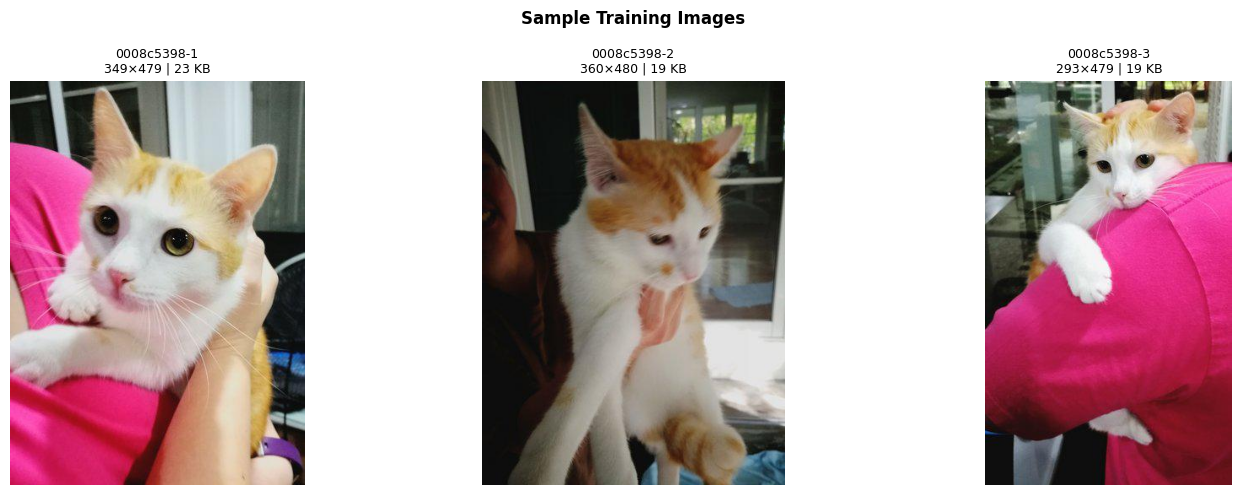

In [16]:
img_files = sorted(os.listdir(cfg.RAW_TRAIN_IMAGES))[:3]
sample_img_ids = [(f.rsplit("-", 1)[0], int(f.rsplit("-", 1)[1].replace(".jpg", ""))) for f in img_files]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (pet_id, idx) in zip(axes, sample_img_ids):
    img = load_image(pet_id, idx, split="train")
    img_path = cfg.RAW_TRAIN_IMAGES / f"{pet_id}-{idx}.jpg"
    file_size_kb = img_path.stat().st_size / 1024

    ax.imshow(np.array(img))
    ax.set_title(f"{pet_id}-{idx}\n{img.size[0]}×{img.size[1]} | {file_size_kb:.0f} KB",
                 fontsize=9)
    ax.axis("off")

plt.suptitle("Sample Training Images", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

---
## 9 · Data Inventory Summary

Consolidated view of all data sources: format, row/file count, column count, and memory footprint.

In [17]:
# File inventory for raw data directory
inventory_df = get_file_inventory(cfg.DATA_RAW)
inventory_df

,subdirectory,extension,file_count,total_size_mb
0,(root),.csv,9,0.0200
1,(root),.zip,1,1987.0400
2,test,.csv,2,1.6200
3,test_images,.jpg,14465,373.8100
4,test_metadata,.json,14465,73.6400
5,test_sentiment,.json,3865,15.7400
6,train,.csv,1,6.3800
7,train_images,.jpg,58311,1531.7200
8,train_metadata,.json,58311,298.2800
9,train_sentiment,.json,14442,64.4400


In [19]:
# Build consolidated data inventory
train_mem = df_train.memory_usage(deep=True).sum() / 1_048_576
test_mem  = df_test.memory_usage(deep=True).sum() / 1_048_576

n_train_images = len(list(cfg.RAW_TRAIN_IMAGES.glob("*.jpg")))
n_test_images  = len(list(cfg.RAW_TEST_IMAGES.glob("*.jpg")))
n_train_meta   = len(list(cfg.RAW_TRAIN_METADATA.glob("*.json")))
n_test_meta    = len(list(cfg.RAW_TEST_METADATA.glob("*.json")))
n_train_sent   = len(list(cfg.RAW_TRAIN_SENTIMENT.glob("*.json")))
n_test_sent    = len(list(cfg.RAW_TEST_SENTIMENT.glob("*.json")))

data_inventory = pd.DataFrame([
    {"Source": "train.csv",         "Format": "CSV",  "Rows/Files": df_train.shape[0],
     "Columns": df_train.shape[1],  "Memory (MB)": round(train_mem, 2)},
    {"Source": "test.csv",          "Format": "CSV",  "Rows/Files": df_test.shape[0],
     "Columns": df_test.shape[1],   "Memory (MB)": round(test_mem, 2)},
    {"Source": "breed_labels.csv",  "Format": "CSV",  "Rows/Files": df_breeds.shape[0],
     "Columns": df_breeds.shape[1], "Memory (MB)": "<0.01"},
    {"Source": "color_labels.csv",  "Format": "CSV",  "Rows/Files": df_colors.shape[0],
     "Columns": df_colors.shape[1], "Memory (MB)": "<0.01"},
    {"Source": "state_labels.csv",  "Format": "CSV",  "Rows/Files": df_states.shape[0],
     "Columns": df_states.shape[1], "Memory (MB)": "<0.01"},
    {"Source": "train_images/",     "Format": "JPEG", "Rows/Files": n_train_images,
     "Columns": "—",               "Memory (MB)": "—"},
    {"Source": "test_images/",      "Format": "JPEG", "Rows/Files": n_test_images,
     "Columns": "—",               "Memory (MB)": "—"},
    {"Source": "train_metadata/",   "Format": "JSON", "Rows/Files": n_train_meta,
     "Columns": "—",               "Memory (MB)": "—"},
    {"Source": "test_metadata/",    "Format": "JSON", "Rows/Files": n_test_meta,
     "Columns": "—",               "Memory (MB)": "—"},
    {"Source": "train_sentiment/",  "Format": "JSON", "Rows/Files": n_train_sent,
     "Columns": "—",               "Memory (MB)": "—"},
    {"Source": "test_sentiment/",   "Format": "JSON", "Rows/Files": n_test_sent,
     "Columns": "—",               "Memory (MB)": "—"},
])

data_inventory.style.set_caption("Data Inventory Summary").hide(axis="index")

Source,Format,Rows/Files,Columns,Memory (MB)
train.csv,CSV,14993,24,11.180000
test.csv,CSV,3972,23,2.770000
breed_labels.csv,CSV,307,3,<0.01
color_labels.csv,CSV,7,2,<0.01
state_labels.csv,CSV,15,2,<0.01
train_images/,JPEG,58311,—,—
test_images/,JPEG,14465,—,—
train_metadata/,JSON,58311,—,—
test_metadata/,JSON,14465,—,—
train_sentiment/,JSON,14442,—,—


---
## 10 · Validation Gate

Assert expected shapes, column names, and structural integrity.  
All gates from specification **§3.4** are checked.

In [21]:
gate_results: list[dict] = []

def check_gate(gate_id: str, description: str, condition: bool) -> None:
    """Register a validation-gate result and raise on failure."""
    status = "PASS ✅" if condition else "FAIL ❌"
    gate_results.append(
        {"Gate": gate_id, "Check": description, "Result": status}
    )
    if not condition:
        raise AssertionError(f"{gate_id} FAILED: {description}")


# G01-1 — train.csv row count
check_gate("G01-1", "train.csv row count == 14,993",
           df_train.shape[0] == 14_993)

# G01-2 — test.csv row count
check_gate("G01-2", "test.csv row count == 3,972",
           df_test.shape[0] == 3_972)

# G01-3 — train.csv column count
check_gate("G01-3", "train.csv column count == 24",
           df_train.shape[1] == 24)

# G01-4 — test.csv column count
check_gate("G01-4", "test.csv column count == 23 (no AdoptionSpeed)",
           df_test.shape[1] == 23)

# G01-5 — AdoptionSpeed presence
check_gate("G01-5", "AdoptionSpeed in train, absent in test",
           "AdoptionSpeed" in df_train.columns and "AdoptionSpeed" not in df_test.columns)

# G01-6 — breed_labels row count
check_gate("G01-6", "breed_labels.csv row count == 307",
           df_breeds.shape[0] == 307)

# G01-7 — color_labels row count
check_gate("G01-7", "color_labels.csv row count == 7",
           df_colors.shape[0] == 7)

# G01-8 — state_labels row count
check_gate("G01-8", "state_labels.csv row count == 15",
           df_states.shape[0] == 15)

# G01-9 — All expected columns present in train.csv
check_gate("G01-9", "All expected columns present in train.csv",
           list(df_train.columns) == EXPECTED_TRAIN_COLUMNS)

# G01-10 — PetID uniqueness
check_gate("G01-10", "PetID unique in train and test",
           df_train["PetID"].is_unique and df_test["PetID"].is_unique)

# ── Summary table ───────────────────────────────────────────────
gate_df = pd.DataFrame(gate_results)
gate_df.style.map(
    lambda v: "background-color: #d4edda" if "PASS" in str(v)
              else "background-color: #f8d7da" if "FAIL" in str(v) else "",
    subset=["Result"]
).set_caption("Validation Gate Results — Notebook 01").hide(axis="index")

Gate,Check,Result
G01-1,"train.csv row count == 14,993",PASS ✅
G01-2,"test.csv row count == 3,972",PASS ✅
G01-3,train.csv column count == 24,PASS ✅
G01-4,test.csv column count == 23 (no AdoptionSpeed),PASS ✅
G01-5,"AdoptionSpeed in train, absent in test",PASS ✅
G01-6,breed_labels.csv row count == 307,PASS ✅
G01-7,color_labels.csv row count == 7,PASS ✅
G01-8,state_labels.csv row count == 15,PASS ✅
G01-9,All expected columns present in train.csv,PASS ✅
G01-10,PetID unique in train and test,PASS ✅


---
## 11 · Persist Data Inventory Report

In [22]:
# Build the artifact
report = {
    "generated_at": datetime.now(timezone.utc).isoformat(),
    "notebook": "01_data_ingestion",
    "tabular": {
        "train": {
            "rows": int(df_train.shape[0]),
            "columns": int(df_train.shape[1]),
            "column_names": list(df_train.columns),
            "dtypes": {c: str(d) for c, d in df_train.dtypes.items()},
            "memory_mb": round(train_mem, 2),
            "null_counts": df_train.isnull().sum().to_dict(),
        },
        "test": {
            "rows": int(df_test.shape[0]),
            "columns": int(df_test.shape[1]),
            "column_names": list(df_test.columns),
            "dtypes": {c: str(d) for c, d in df_test.dtypes.items()},
            "memory_mb": round(test_mem, 2),
            "null_counts": df_test.isnull().sum().to_dict(),
        },
    },
    "reference_tables": {
        "breed_labels": {"rows": int(df_breeds.shape[0]), "columns": int(df_breeds.shape[1])},
        "color_labels": {"rows": int(df_colors.shape[0]), "columns": int(df_colors.shape[1])},
        "state_labels": {"rows": int(df_states.shape[0]), "columns": int(df_states.shape[1])},
    },
    "files": {
        "train_images": int(n_train_images),
        "test_images": int(n_test_images),
        "train_metadata": int(n_train_meta),
        "test_metadata": int(n_test_meta),
        "train_sentiment": int(n_train_sent),
        "test_sentiment": int(n_test_sent),
    },
    "validation_gates": gate_results,
}

report_path = cfg.REPORTS_DIR / "data_inventory.json"
report_path.parent.mkdir(parents=True, exist_ok=True)
with open(report_path, "w", encoding="utf-8") as f:
    json.dump(report, f, indent=2, default=str)

logger.info("Data inventory report saved to %s", report_path)
print(f"\n✅ Artifact persisted: {report_path}")

00:46:00  INFO      Data inventory report saved to /workspaces/adoption_accelerator/reports/data_inventory.json



✅ Artifact persisted: /workspaces/adoption_accelerator/reports/data_inventory.json


---
## 12 · Summary

| Metric | Value |
|--------|-------|
| Train rows | 14,993 |
| Test rows | 3,972 |
| Train columns | 24 |
| Test columns | 23 |
| Reference tables | 3 (breed: 307, color: 7, state: 15) |
| Validation gates | 10/10 passed |
| Artifact | `reports/data_inventory.json` |

**Key observations:**
- `AdoptionSpeed` target is present only in train (as expected).
- `Name` and `Description` contain nulls — to be assessed in Notebook 02.
- Sentiment files are per-listing (not per-image); metadata and images are per-photo.
- All validation gates passed — data is structurally consistent.

---

**Next →** `02_data_validation.ipynb` — Schema validation, referential integrity, and domain checks.